In [1]:
import polars as pl

In [2]:
data_jan_2009 = pl.read_parquet("C:/Users/ekadw/Documents/DATA/NY_Taxi/2009/yellow_taxi/yellow_tripdata_2009-01.parquet", 
                                columns=['Trip_Pickup_DateTime','Trip_Dropoff_DateTime','Passenger_Count','Trip_Distance',
                                         'Payment_Type','Fare_Amt','Tip_Amt'])

In [3]:
len(data_jan_2009)

14092413

In [4]:
data_jan_2009.head()

Trip_Pickup_DateTime,Trip_Dropoff_DateTime,Passenger_Count,Trip_Distance,Payment_Type,Fare_Amt,Tip_Amt
str,str,i64,f64,str,f64,f64
"""2009-01-04 02:52:00""","""2009-01-04 03:02:00""",1,2.63,"""CASH""",8.9,0.0
"""2009-01-04 03:31:00""","""2009-01-04 03:38:00""",3,4.55,"""Credit""",12.1,2.0
"""2009-01-03 15:43:00""","""2009-01-03 15:57:00""",5,10.35,"""Credit""",23.7,4.74
"""2009-01-01 20:52:58""","""2009-01-01 21:14:00""",1,5.0,"""CREDIT""",14.9,3.05
"""2009-01-24 16:18:23""","""2009-01-24 16:24:56""",1,0.4,"""CASH""",3.7,0.0


In [5]:
data_jan_2009.columns

['Trip_Pickup_DateTime',
 'Trip_Dropoff_DateTime',
 'Passenger_Count',
 'Trip_Distance',
 'Payment_Type',
 'Fare_Amt',
 'Tip_Amt']

In [6]:
data_jan_2009 = data_jan_2009.rename({
    "Trip_Pickup_DateTime": "trip_pickup_dateTime",
    "Trip_Dropoff_DateTime": "trip_dropoff_dateTime",
    "Passenger_Count": "passenger_count",
    "Trip_Distance": "trip_distance",
    "Payment_Type": "payment_type",
    "Fare_Amt": "fare_amt",
    "Tip_Amt": "tip_amt"
})

In [10]:
data_jan_2009 = data_jan_2009.filter(
    (pl.col("passenger_count") >= 0) & (pl.col("trip_distance") >= 0) & (pl.col("trip_distance") <= 50) & 
    (pl.col("fare_amt") >= 0) & (pl.col("tip_amt") >= 0)
)
len(data_jan_2009)

14092413

In [11]:
mapping = {
    "Credit": 0,
    "CREDIT": 0,
    "CASH": 1,
    "Cash": 1,
    "No Charge": 2,
    "Dispute": 3
}

data_jan_2009 = data_jan_2009.with_columns(
    pl.col("payment_type").replace(mapping)
)

In [12]:
data_jan_2009.head()

trip_pickup_dateTime,trip_dropoff_dateTime,passenger_count,trip_distance,payment_type,fare_amt,tip_amt
str,str,i64,f64,str,f64,f64
"""2009-01-04 02:52:00""","""2009-01-04 03:02:00""",1,2.63,"""1""",8.9,0.0
"""2009-01-04 03:31:00""","""2009-01-04 03:38:00""",3,4.55,"""0""",12.1,2.0
"""2009-01-03 15:43:00""","""2009-01-03 15:57:00""",5,10.35,"""0""",23.7,4.74
"""2009-01-01 20:52:58""","""2009-01-01 21:14:00""",1,5.0,"""0""",14.9,3.05
"""2009-01-24 16:18:23""","""2009-01-24 16:24:56""",1,0.4,"""1""",3.7,0.0


In [14]:
data_jan_2009 = data_jan_2009.with_columns([
    pl.col("trip_pickup_dateTime").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S"),
    pl.col("trip_dropoff_dateTime").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S"),
    pl.col("payment_type").cast(pl.Int64)
])

In [16]:
data_jan_2009.head()

trip_pickup_dateTime,trip_dropoff_dateTime,passenger_count,trip_distance,payment_type,fare_amt,tip_amt
datetime[μs],datetime[μs],i64,f64,i64,f64,f64
2009-01-04 02:52:00,2009-01-04 03:02:00,1,2.63,1,8.9,0.0
2009-01-04 03:31:00,2009-01-04 03:38:00,3,4.55,0,12.1,2.0
2009-01-03 15:43:00,2009-01-03 15:57:00,5,10.35,0,23.7,4.74
2009-01-01 20:52:58,2009-01-01 21:14:00,1,5.0,0,14.9,3.05
2009-01-24 16:18:23,2009-01-24 16:24:56,1,0.4,1,3.7,0.0


In [17]:
data_jan_2009 = data_jan_2009.with_columns(
    ((pl.col("trip_dropoff_dateTime") - pl.col("trip_pickup_dateTime")).dt.total_seconds() / 86400)
    .cast(pl.Int64)
    .alias("duration_days")
)

In [18]:
data_jan_2009.head()

trip_pickup_dateTime,trip_dropoff_dateTime,passenger_count,trip_distance,payment_type,fare_amt,tip_amt,duration_days
datetime[μs],datetime[μs],i64,f64,i64,f64,f64,i64
2009-01-04 02:52:00,2009-01-04 03:02:00,1,2.63,1,8.9,0.0,0
2009-01-04 03:31:00,2009-01-04 03:38:00,3,4.55,0,12.1,2.0,0
2009-01-03 15:43:00,2009-01-03 15:57:00,5,10.35,0,23.7,4.74,0
2009-01-01 20:52:58,2009-01-01 21:14:00,1,5.0,0,14.9,3.05,0
2009-01-24 16:18:23,2009-01-24 16:24:56,1,0.4,1,3.7,0.0,0


In [19]:
data_jan_2009 = data_jan_2009.filter(
    (pl.col("duration_days") == 0) 
)
len(data_jan_2009)

14092358

In [20]:
data_jan_2009 = data_jan_2009.with_columns(
    ((pl.col("trip_dropoff_dateTime") - pl.col("trip_pickup_dateTime")).dt.total_seconds())
    .cast(pl.Int64)
    .alias("duration_seconds")
)

In [21]:
data_jan_2009.head()

trip_pickup_dateTime,trip_dropoff_dateTime,passenger_count,trip_distance,payment_type,fare_amt,tip_amt,duration_days,duration_seconds
datetime[μs],datetime[μs],i64,f64,i64,f64,f64,i64,i64
2009-01-04 02:52:00,2009-01-04 03:02:00,1,2.63,1,8.9,0.0,0,600
2009-01-04 03:31:00,2009-01-04 03:38:00,3,4.55,0,12.1,2.0,0,420
2009-01-03 15:43:00,2009-01-03 15:57:00,5,10.35,0,23.7,4.74,0,840
2009-01-01 20:52:58,2009-01-01 21:14:00,1,5.0,0,14.9,3.05,0,1262
2009-01-24 16:18:23,2009-01-24 16:24:56,1,0.4,1,3.7,0.0,0,393


In [22]:
data_jan_2009 = data_jan_2009.drop(["trip_pickup_dateTime", "trip_dropoff_dateTime", "duration_days"])

In [23]:
data_jan_2009.head()

passenger_count,trip_distance,payment_type,fare_amt,tip_amt,duration_seconds
i64,f64,i64,f64,f64,i64
1,2.63,1,8.9,0.0,600
3,4.55,0,12.1,2.0,420
5,10.35,0,23.7,4.74,840
1,5.0,0,14.9,3.05,1262
1,0.4,1,3.7,0.0,393


In [24]:
data_jan_2009 = data_jan_2009.with_columns(
    pl.when(pl.col("tip_amt") == 0)
      .then(0)
      .otherwise(1)
      .alias("tip_or_no")
)

In [25]:
data_jan_2009 = data_jan_2009.drop(["tip_amt"])

In [26]:
data_jan_2009.head()

passenger_count,trip_distance,payment_type,fare_amt,duration_seconds,tip_or_no
i64,f64,i64,f64,i64,i32
1,2.63,1,8.9,600,0
3,4.55,0,12.1,420,1
5,10.35,0,23.7,840,1
1,5.0,0,14.9,1262,1
1,0.4,1,3.7,393,0


In [28]:
data_jan_2009["tip_or_no"].value_counts()

tip_or_no,count
i32,u32
0,11155831
1,2936527


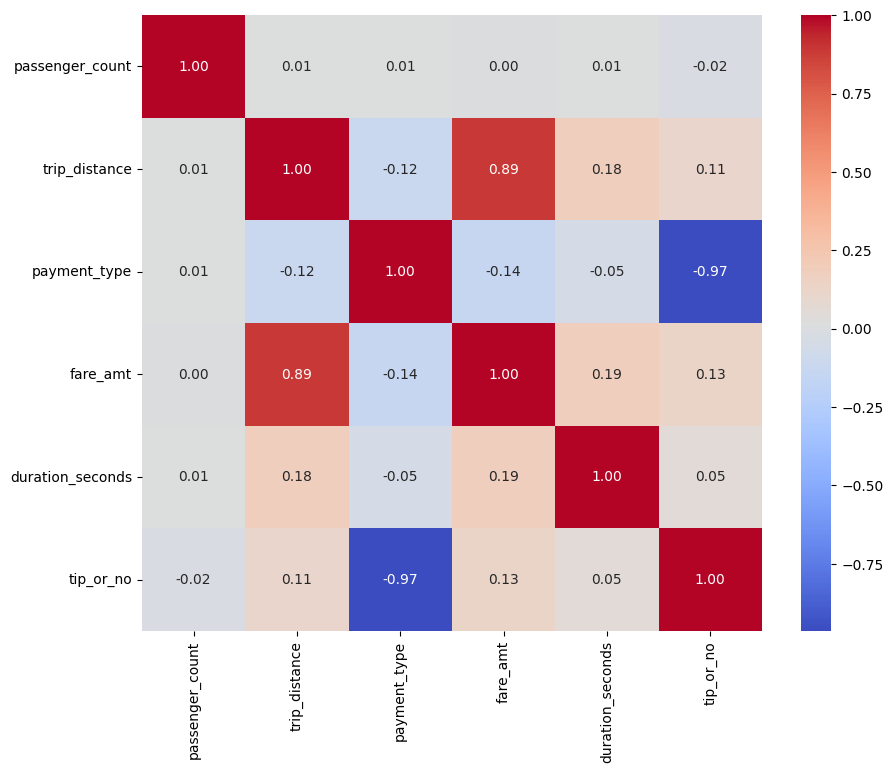

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_df = data_jan_2009.select(pl.all().cast(pl.Float64)).to_pandas().corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [43]:
#y = data_jan_2009['tip_or_no']
#X = data_jan_2009.drop(['tip_or_no'])

y = data_jan_2009.select('tip_or_no').to_numpy().ravel().astype(int)
X = data_jan_2009.drop(['tip_or_no']).to_numpy()


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [36]:
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression())
])

pipeline.fit(X_train, y_train)

,steps,"[('smote', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'


In [37]:
pipeline.score(X_test,y_test)

0.9931814117720523

Accuracy: 0.9931643093370179
Confusion Matrix:
 [[11063772    92059]
 [    4272  2932255]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00  11155831
           1       0.97      1.00      0.98   2936527

    accuracy                           0.99  14092358
   macro avg       0.98      1.00      0.99  14092358
weighted avg       0.99      0.99      0.99  14092358

ROC AUC: 0.9958318103698416


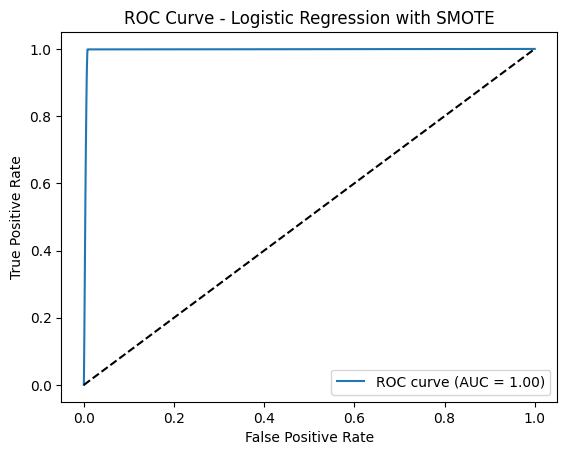

In [39]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# --- 1. Example data (replace with your own X, y)
#X, y = make_classification(
#    n_samples=2000, n_features=10, n_informative=5, n_redundant=2,
#    weights=[0.9, 0.1], random_state=42
#)

# --- 2. Build pipeline: SMOTE -> Scaling -> Logistic Regression
model = Pipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(solver='liblinear', random_state=42))
])

# --- 3. Cross-validation (Stratified K-Fold preserves class balance)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use cross_val_predict to get out-of-fold predictions
y_pred = cross_val_predict(model, X, y, cv=cv, method='predict')
y_proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]

# --- 4. Metrics
acc = accuracy_score(y, y_pred)
cm = confusion_matrix(y, y_pred)
roc_auc = roc_auc_score(y, y_proba)

print("Accuracy:", acc)
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", classification_report(y, y_pred))
print("ROC AUC:", roc_auc)

# --- 5. ROC curve plot
fpr, tpr, thresholds = roc_curve(y, y_proba)

plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression with SMOTE')
plt.legend()
plt.show()

CV Accuracy: 0.6648014712939265
Confusion Matrix (CV):
[[6521613 2403051]
 [1375939  973283]]
AUC (CV): 0.6110430074745824
Test Accuracy: 0.6652225035409257
Confusion Matrix (Test):
[[1631520  599647]
 [ 343914  243391]]
AUC (Test): 0.6117767017328857


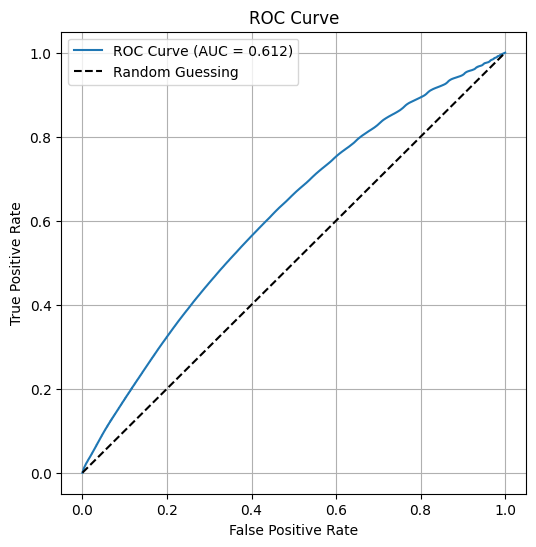

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# =======================
# 1. Prepare data
# =======================
# X: features (numpy array or pandas DataFrame)
# y: labels (numpy array or pandas Series)
# Example:
# X, y = ...
# Ensure y is numeric (0/1), not strings

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =======================
# 2. Define pipeline
# =======================
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(solver='lbfgs', max_iter=1000))
])

# =======================
# 3. Cross-validation (StratifiedKFold)
# =======================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_cv = cross_val_predict(pipeline, X_train, y_train, cv=cv, method='predict')
y_prob_cv = cross_val_predict(pipeline, X_train, y_train, cv=cv, method='predict_proba')[:, 1]

print("CV Accuracy:", accuracy_score(y_train, y_pred_cv))
print("Confusion Matrix (CV):")
print(confusion_matrix(y_train, y_pred_cv))
print("AUC (CV):", roc_auc_score(y_train, y_prob_cv))

# =======================
# 4. Fit final model on full training set
# =======================
pipeline.fit(X_train, y_train)
y_pred_test = pipeline.predict(X_test)
y_prob_test = pipeline.predict_proba(X_test)[:, 1]

# =======================
# 5. Evaluate on test set
# =======================
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("Confusion Matrix (Test):")
print(confusion_matrix(y_test, y_pred_test))
print("AUC (Test):", roc_auc_score(y_test, y_prob_test))

# =======================
# 6. Plot ROC curve
# =======================
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_prob_test):.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Bring back the dominant feature first before running this code
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# ---------------------------
# Example: Assume you already have X_train, y_train
# ---------------------------

# 1. Define the pipeline
pipeline = Pipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(
        n_estimators=200,        # More trees for better stability
        max_depth=None,         # Let trees expand fully (tune as needed)
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight=None,      # You can try "balanced" if still imbalanced
        random_state=42,
        n_jobs=-1               # Use all CPU cores
    ))
])

# 2. Define cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Get cross-validated predictions
y_pred_cv = cross_val_predict(
    pipeline, X_train, y_train, cv=cv, method='predict', n_jobs=-1
)
y_prob_cv = cross_val_predict(
    pipeline, X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1
)[:, 1]  # Probability for positive class

# 4. Confusion Matrix
cm = confusion_matrix(y_train, y_pred_cv)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Confusion Matrix (Cross-validated)")
plt.show()

# 5. ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_train, y_prob_cv)
auc_score = roc_auc_score(y_train, y_prob_cv)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Cross-validated)")
plt.legend()
plt.grid(True)
plt.show()

print(f"ROC-AUC Score: {auc_score:.3f}")


In [30]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
import numpy as np

# Example dataset
X, y = make_classification(n_samples=1000, n_features=10, n_classes=2,
                           weights=[0.9, 0.1], random_state=42)

# Split into train/test before applying SMOTE (apply only on train!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("Original dataset shape:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Resampled dataset shape:", dict(zip(*np.unique(y_resampled, return_counts=True))))


Original dataset shape: {np.int64(0): np.int64(628), np.int64(1): np.int64(72)}
Resampled dataset shape: {np.int64(0): np.int64(628), np.int64(1): np.int64(628)}
